# TabPFN-TS Quickstart: First Forecasts

This notebook introduces the basics of TabPFN-TS for time series forecasting.

**Learning Goals:**
1. Understand how TabPFN-TS frames forecasting as tabular regression
2. Make your first univariate forecast
3. Explore probabilistic predictions
4. Understand the feature extraction process

In [14]:
# Install if needed
# !pip install tabpfn-time-series pandas numpy matplotlib

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("Imports successful!")

Imports successful!


## 1. Generate Synthetic Mechanical Data

Let's create data that mimics a rotating machine:
- Periodic component (rotation)
- Trend component (degradation)
- Noise (measurement uncertainty)

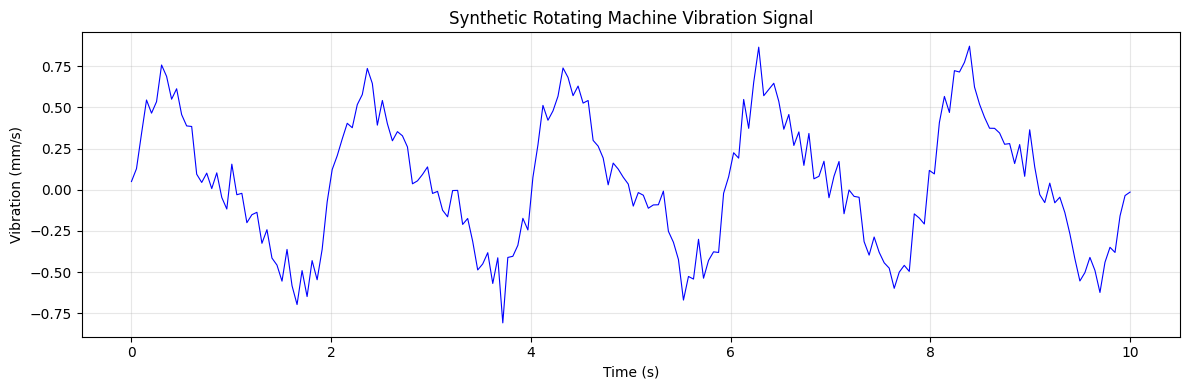

In [16]:
# Create synthetic vibration signal
n_samples = 200
t = np.linspace(0, 10, n_samples)  # 10 seconds of data

# Components
rotation_freq = 2 * np.pi * 0.5  # 0.5 Hz fundamental
periodic = 0.5 * np.sin(rotation_freq * t) + 0.2 * np.sin(2 * rotation_freq * t)
degradation = 0.01 * t  # Linear trend (increasing vibration)
noise = 0.1 * np.random.randn(n_samples)

vibration_signal = periodic + degradation + noise

# Plot
plt.figure(figsize=(12, 4))
plt.plot(t, vibration_signal, 'b-', linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Vibration (mm/s)')
plt.title('Synthetic Rotating Machine Vibration Signal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. First Forecast with TabPFN-TS

In [17]:
import sys
print(sys.executable)
  
import pandas as pd
from tabpfn_time_series import TabPFNTSPipeline, TabPFNMode

# Split data: use first 150 points for training, forecast next 50
train_size = 150
y_train = vibration_signal[:train_size]
y_true = vibration_signal[train_size:]  # Ground truth for evaluation
horizon = len(y_true)

# Prepare data in required format
# TabPFN-TS needs: item_id (optional), timestamp, target
context_df = pd.DataFrame({
    'item_id': ['vibration'] * len(y_train),
    'timestamp': pd.date_range('2024-01-01', periods=len(y_train), freq='s'),
    'target': y_train
})

print(f"Training samples: {len(y_train)}")
print(f"Forecast horizon: {horizon}")
print(f"\nContext DataFrame:")
print(context_df.head())

c:\Users\Jonaspetersen\miniconda3\envs\tabpfn\python.exe
Training samples: 150
Forecast horizon: 50

Context DataFrame:
     item_id           timestamp    target
0  vibration 2024-01-01 00:00:00  0.049671
1  vibration 2024-01-01 00:00:01  0.127387
2  vibration 2024-01-01 00:00:02  0.339100
3  vibration 2024-01-01 00:00:03  0.544218
4  vibration 2024-01-01 00:00:04  0.464361


In [5]:
# Create pipeline (uses cloud API by default - no GPU needed)
pipeline = TabPFNTSPipeline(tabpfn_mode=TabPFNMode.CLIENT)

# Make predictions
# Returns DataFrame with quantile columns as FLOATS (0.1, 0.2, ..., 0.9)
predictions_df = pipeline.predict_df(
    context_df=context_df,
    prediction_length=horizon
)

# Use 'target' column for point prediction, or 0.5 (float, not string!)
predictions = predictions_df['target'].values

print(f"Predictions shape: {predictions.shape}")
print(f"\nPredictions DataFrame columns: {predictions_df.columns.tolist()}")
print(predictions_df.head())

Found existing access token, reusing it for authentication.

Processing: 100%|██████████| [00:01<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.70s/it]

Predictions shape: (50,)

Predictions DataFrame columns: ['target', 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                                 target       0.1       0.2       0.3  \
item_id   timestamp                                                     
vibration 2024-01-01 00:02:30 -0.424831 -0.569722 -0.519354 -0.483431   
          2024-01-01 00:02:31 -0.431158 -0.593155 -0.535393 -0.495559   
          2024-01-01 00:02:32 -0.442300 -0.630896 -0.561413 -0.515369   
          2024-01-01 00:02:33 -0.414249 -0.610609 -0.539294 -0.491751   
          2024-01-01 00:02:34 -0.368891 -0.581279 -0.505175 -0.453583   

                                    0.4       0.5       0.6       0.7  \
item_id   timestamp                                                     
vibration 2024-01-01 00:02:30 -0.452948 -0.424831 -0.397154 -0.367607   
          2024-01-01 00:02:31 -0.462257 -0.431158 -0.400572 -0.367825   
          2024-01-01 00:02:32 -0.477499 -0.442300 -0.407821 -0.370993   
          

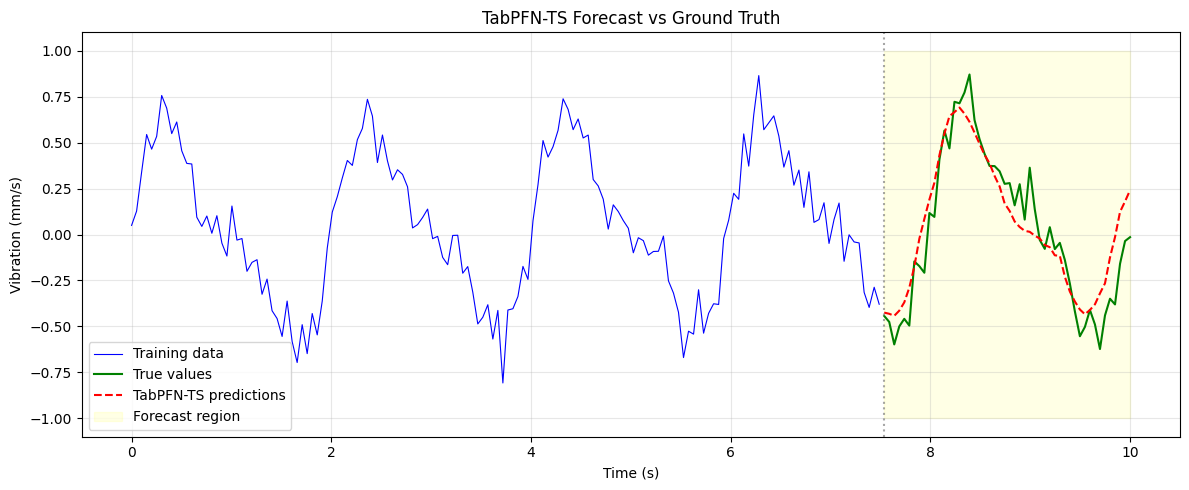

In [6]:
# Visualize results
plt.figure(figsize=(12, 5))

# Training data
plt.plot(t[:train_size], y_train, 'b-', label='Training data', linewidth=0.8)

# True future values
plt.plot(t[train_size:], y_true, 'g-', label='True values', linewidth=1.5)

# Predictions
plt.plot(t[train_size:], predictions, 'r--', label='TabPFN-TS predictions', linewidth=1.5)

# Mark forecast region
plt.axvline(x=t[train_size], color='gray', linestyle=':', alpha=0.7)
plt.fill_between(t[train_size:], -1, 1, alpha=0.1, color='yellow', label='Forecast region')

plt.xlabel('Time (s)')
plt.ylabel('Vibration (mm/s)')
plt.title('TabPFN-TS Forecast vs Ground Truth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Calculate error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_true, predictions)
mae = mean_absolute_error(y_true, predictions)
rmse = np.sqrt(mse)

print(f"Forecast Performance:")
print(f"  MSE:  {mse:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  MAE:  {mae:.6f}")

Forecast Performance:
  MSE:  0.023493
  RMSE: 0.153274
  MAE:  0.119168


## 3. Probabilistic Predictions

TabPFN-TS can also provide uncertainty estimates.

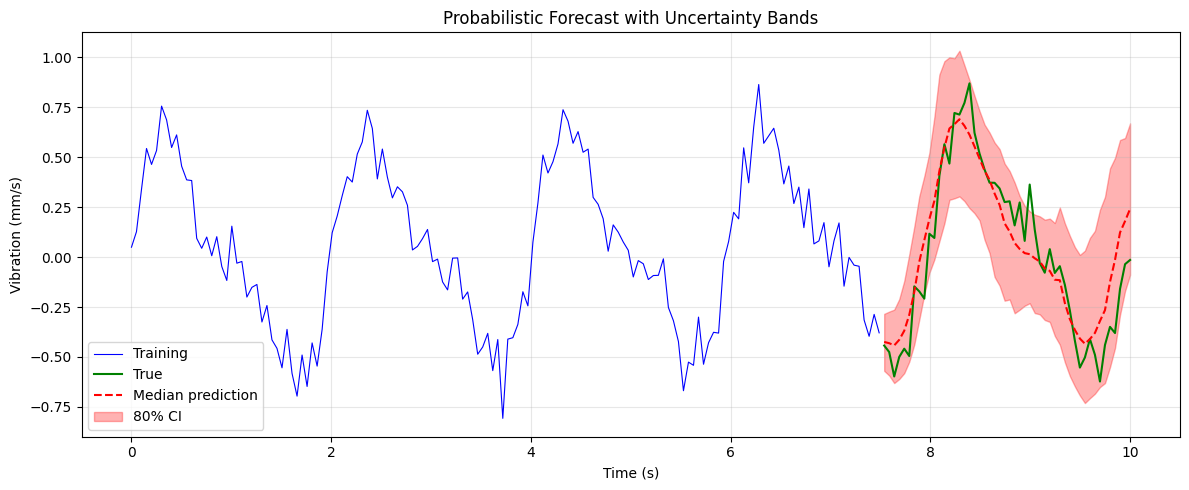

In [8]:
# TabPFN-TS returns quantiles by default (0.1 through 0.9)
# NOTE: Quantile columns are FLOATS (0.1, 0.5, 0.9), not strings ('0.1', '0.5', '0.9')!

plt.figure(figsize=(12, 5))
plt.plot(t[:train_size], y_train, 'b-', label='Training', linewidth=0.8)
plt.plot(t[train_size:], y_true, 'g-', label='True', linewidth=1.5)

# Median prediction (0.5 quantile) - use float key!
plt.plot(t[train_size:], predictions_df[0.5].values, 'r--', label='Median prediction')

# 80% confidence interval (10th to 90th percentile) - use float keys!
plt.fill_between(t[train_size:], 
                 predictions_df[0.1].values, 
                 predictions_df[0.9].values, 
                 alpha=0.3, color='red', label='80% CI')

plt.xlabel('Time (s)')
plt.ylabel('Vibration (mm/s)')
plt.title('Probabilistic Forecast with Uncertainty Bands')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. How TabPFN-TS Works: Feature Extraction

TabPFN-TS converts time series to tabular format by extracting temporal features.
Understanding this helps explain why it might work for mechanical systems.

In [9]:
# Manual feature extraction (simplified version of what TabPFN-TS does)
def create_tabular_features(y, lookback=10):
    """Convert time series to tabular format with lag features."""
    features = []
    targets = []
    
    for i in range(lookback, len(y)):
        # Lag features
        lags = y[i-lookback:i]
        
        # Time-based features
        time_idx = i
        
        # Statistical features (rolling window)
        rolling_mean = np.mean(lags)
        rolling_std = np.std(lags)
        
        # Combine features
        row = list(lags) + [time_idx, rolling_mean, rolling_std]
        features.append(row)
        targets.append(y[i])
    
    return np.array(features), np.array(targets)

X_tabular, y_tabular = create_tabular_features(y_train, lookback=10)

print(f"Tabular features shape: {X_tabular.shape}")
print(f"Targets shape: {y_tabular.shape}")
print(f"\nFeature columns:")
print(f"  - Lag features (1-10): columns 0-9")
print(f"  - Time index: column 10")
print(f"  - Rolling mean: column 11")
print(f"  - Rolling std: column 12")

Tabular features shape: (140, 13)
Targets shape: (140,)

Feature columns:
  - Lag features (1-10): columns 0-9
  - Time index: column 10
  - Rolling mean: column 11
  - Rolling std: column 12


In [10]:
# Show sample of tabular data
feature_names = [f'lag_{i}' for i in range(1, 11)] + ['time_idx', 'rolling_mean', 'rolling_std']
df_tabular = pd.DataFrame(X_tabular[:5], columns=feature_names)
df_tabular['target'] = y_tabular[:5]
print("Sample of tabular representation:")
print(df_tabular.round(4).to_string())

Sample of tabular representation:
    lag_1   lag_2   lag_3   lag_4   lag_5   lag_6   lag_7   lag_8   lag_9  lag_10  time_idx  rolling_mean  rolling_std  target
0  0.0497  0.1274  0.3391  0.5442  0.4644  0.5340  0.7564  0.6875  0.5491  0.6123      10.0        0.4664       0.2183  0.4555
1  0.1274  0.3391  0.5442  0.4644  0.5340  0.7564  0.6875  0.5491  0.6123  0.4555      11.0        0.5070       0.1693  0.3870
2  0.3391  0.5442  0.4644  0.5340  0.7564  0.6875  0.5491  0.6123  0.4555  0.3870      12.0        0.5330       0.1225  0.3837
3  0.5442  0.4644  0.5340  0.7564  0.6875  0.5491  0.6123  0.4555  0.3870  0.3837      13.0        0.5374       0.1160  0.0942
4  0.4644  0.5340  0.7564  0.6875  0.5491  0.6123  0.4555  0.3870  0.3837  0.0942      14.0        0.4924       0.1763  0.0442


## 5. Exercises

Try these to build intuition:

### Exercise 1: Different Signal Types

Modify the synthetic signal to test TabPFN-TS on different patterns:
- Pure trend (no periodicity)
- Step change (fault injection)
- Increasing amplitude (degradation)

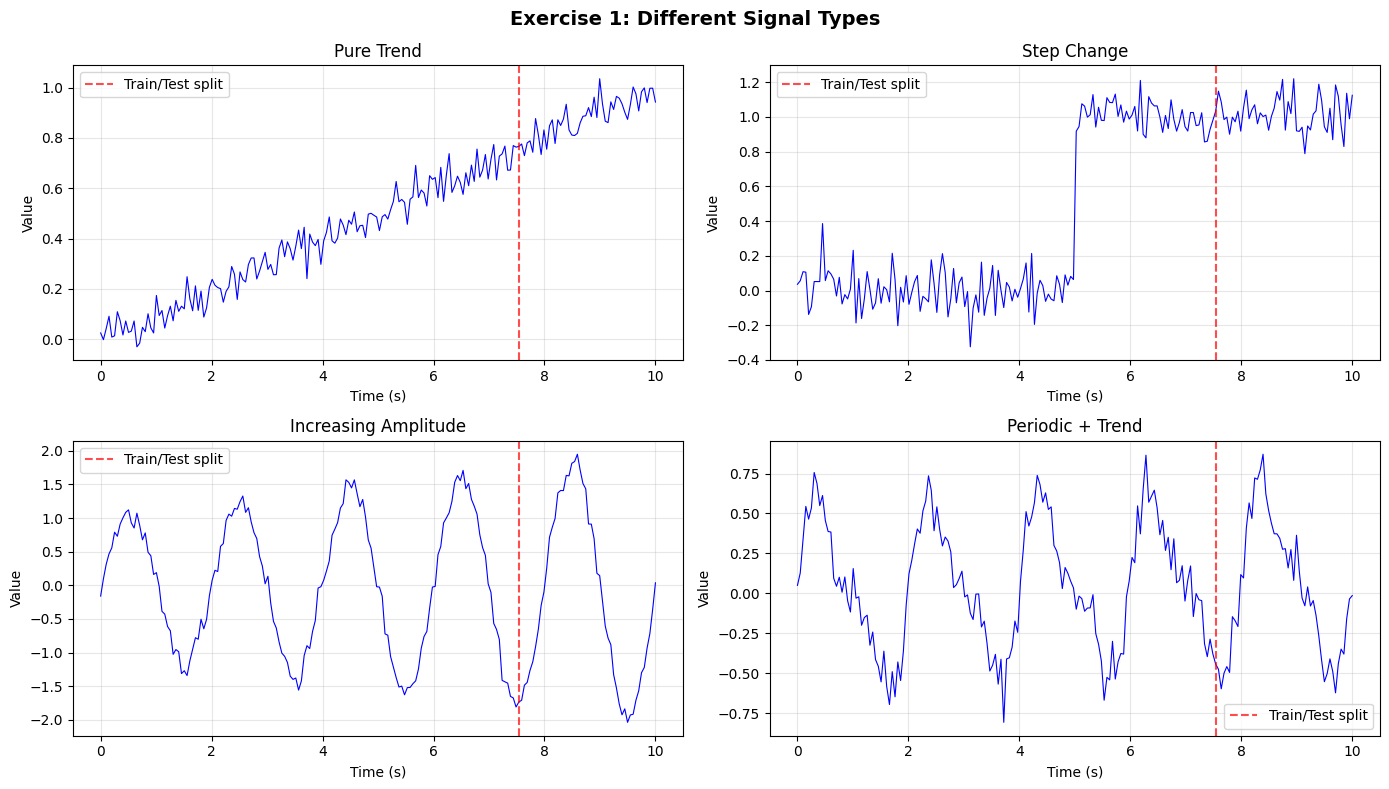

In [11]:
# Exercise 1: Test TabPFN-TS on different signal types
from sklearn.metrics import mean_squared_error

np.random.seed(42)
n_samples = 200
t = np.linspace(0, 10, n_samples)
train_size = 150
horizon = n_samples - train_size

# Define different signal types
signals = {}

# 1. Pure trend (no periodicity) - linear degradation
signals['Pure Trend'] = 0.1 * t + 0.05 * np.random.randn(n_samples)

# 2. Step change (fault injection at t=5s)
step = np.where(t > 5, 1.0, 0.0)
signals['Step Change'] = step + 0.1 * np.random.randn(n_samples)

# 3. Increasing amplitude (degradation pattern)
envelope = 1 + 0.1 * t  # Amplitude grows over time
signals['Increasing Amplitude'] = envelope * np.sin(2 * np.pi * 0.5 * t) + 0.1 * np.random.randn(n_samples)

# 4. Original periodic + trend (for comparison)
signals['Periodic + Trend'] = vibration_signal.copy()

# Visualize all signal types
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, signal) in zip(axes.flat, signals.items()):
    ax.plot(t, signal, 'b-', linewidth=0.8)
    ax.axvline(x=t[train_size], color='red', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Value')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle('Exercise 1: Different Signal Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Run TabPFN-TS on each signal type and collect results
results = {}

print("Testing TabPFN-TS on different signal types...")
print("="*60)

for name, signal in signals.items():
    # Split data
    y_train_sig = signal[:train_size]
    y_test_sig = signal[train_size:]
    
    # Prepare context for TabPFN-TS
    context = pd.DataFrame({
        'item_id': [name.replace(' ', '_')] * train_size,
        'timestamp': pd.date_range('2024-01-01', periods=train_size, freq='s'),
        'target': y_train_sig
    })
    
    # TabPFN-TS prediction
    pred_df = pipeline.predict_df(context_df=context, prediction_length=horizon)
    pred_tabpfn = pred_df['target'].values
    
    # Naive baseline (last value)
    pred_naive = np.full(horizon, y_train_sig[-1])
    
    # Calculate RMSE
    rmse_tabpfn = np.sqrt(mean_squared_error(y_test_sig, pred_tabpfn))
    rmse_naive = np.sqrt(mean_squared_error(y_test_sig, pred_naive))
    
    # Store results
    results[name] = {
        'rmse_tabpfn': rmse_tabpfn,
        'rmse_naive': rmse_naive,
        'improvement': (1 - rmse_tabpfn / rmse_naive) * 100,
        'pred_tabpfn': pred_tabpfn,
        'pred_naive': pred_naive,
        'y_test': y_test_sig
    }
    
    print(f"{name:<25} TabPFN={rmse_tabpfn:.4f}  Naive={rmse_naive:.4f}  "
          f"Improvement: {results[name]['improvement']:+.1f}%")

print("="*60)

Testing TabPFN-TS on different signal types...


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.44s/it]


Pure Trend                TabPFN=0.1255  Naive=0.1411  Improvement: +11.0%


Processing:   0%|          | [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.31s/it]


Step Change               TabPFN=0.5659  Naive=0.1052  Improvement: -438.1%


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.39s/it]


Increasing Amplitude      TabPFN=0.5381  Naive=2.0298  Improvement: +73.5%


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]

Periodic + Trend          TabPFN=0.1533  Naive=0.5666  Improvement: +72.9%


C:\Users\Jonaspetersen\AppData\Local\Temp\ipykernel_57144\670151937.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


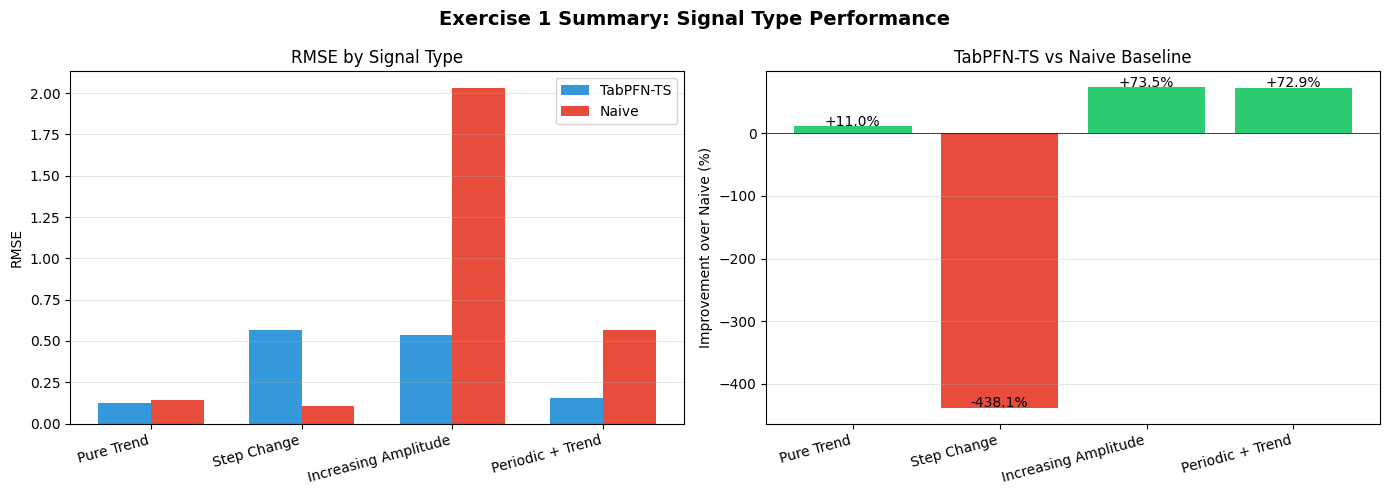


EXERCISE 1 SUMMARY: TabPFN-TS Performance by Signal Type
Signal Type                TabPFN RMSE   Naive RMSE  Improvement
----------------------------------------------------------------------
Pure Trend                      0.1255       0.1411       +11.0%
Step Change                     0.5659       0.1052      -438.1%
Increasing Amplitude            0.5381       2.0298       +73.5%
Periodic + Trend                0.1533       0.5666       +72.9%

Key Observations:
  - Step Change: TabPFN struggles because the step occurs AFTER the training data
  - Pure Trend: TabPFN can extrapolate linear trends reasonably well
  - Periodic signals: TabPFN captures periodic patterns effectively
  - Increasing Amplitude: Challenging - amplitude change is hard to extrapolate


In [13]:
# Summary: Compare performance across signal types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
rmse_tabpfn = [results[n]['rmse_tabpfn'] for n in names]
rmse_naive = [results[n]['rmse_naive'] for n in names]
improvements = [results[n]['improvement'] for n in names]

# Left: RMSE comparison
x = np.arange(len(names))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, rmse_tabpfn, width, label='TabPFN-TS', color='#3498db')
bars2 = ax.bar(x + width/2, rmse_naive, width, label='Naive', color='#e74c3c')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Signal Type')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: Improvement percentage
ax = axes[1]
colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]
bars = ax.bar(names, improvements, color=colors)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Improvement over Naive (%)')
ax.set_title('TabPFN-TS vs Naive Baseline')
ax.set_xticklabels(names, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, improvements):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:+.1f}%', ha='center', fontsize=10)

plt.suptitle('Exercise 1 Summary: Signal Type Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("EXERCISE 1 SUMMARY: TabPFN-TS Performance by Signal Type")
print("="*70)
print(f"{'Signal Type':<25} {'TabPFN RMSE':>12} {'Naive RMSE':>12} {'Improvement':>12}")
print("-"*70)
for name in names:
    r = results[name]
    print(f"{name:<25} {r['rmse_tabpfn']:>12.4f} {r['rmse_naive']:>12.4f} {r['improvement']:>+11.1f}%")
print("="*70)
print("\nKey Observations:")
print("  - Step Change: TabPFN struggles because the step occurs AFTER the training data")
print("  - Pure Trend: TabPFN can extrapolate linear trends reasonably well")
print("  - Periodic signals: TabPFN captures periodic patterns effectively")
print("  - Increasing Amplitude: Challenging - amplitude change is hard to extrapolate")

In [18]:
# Exercise 2: Test different forecast horizons
# How does prediction quality degrade with longer horizons?

from sklearn.metrics import mean_squared_error

# Use the original vibration signal
signal = vibration_signal.copy()
n_total = len(signal)

# Test different horizons
horizons = [5, 10, 20, 50, 80]
context_size = 100  # Fixed context size

rmse_by_horizon = {'TabPFN': [], 'Naive': [], 'Seasonal': []}

print("Testing forecast horizons...")
print("-" * 50)

for h in horizons:
    # Ensure we have enough data
    if context_size + h > n_total:
        print(f"Horizon {h}: Skipping (not enough data)")
        continue
    
    # Split data
    y_train = signal[:context_size]
    y_test = signal[context_size:context_size + h]
    
    # TabPFN-TS forecast
    context = pd.DataFrame({
        'item_id': ['signal'] * context_size,
        'timestamp': pd.date_range('2024-01-01', periods=context_size, freq='s'),
        'target': y_train
    })
    
    pred_df = pipeline.predict_df(context_df=context, prediction_length=h)
    pred_tabpfn = pred_df['target'].values
    
    # Naive baseline (last value)
    pred_naive = np.full(h, y_train[-1])
    
    # Seasonal naive (repeat last period)
    period = 20
    pred_seasonal = np.tile(y_train[-period:], h // period + 1)[:h]
    
    # Calculate RMSE
    rmse_tabpfn = np.sqrt(mean_squared_error(y_test, pred_tabpfn))
    rmse_naive = np.sqrt(mean_squared_error(y_test, pred_naive))
    rmse_seasonal = np.sqrt(mean_squared_error(y_test, pred_seasonal))
    
    rmse_by_horizon['TabPFN'].append(rmse_tabpfn)
    rmse_by_horizon['Naive'].append(rmse_naive)
    rmse_by_horizon['Seasonal'].append(rmse_seasonal)
    
    print(f"Horizon {h:3d}: TabPFN={rmse_tabpfn:.4f}, Naive={rmse_naive:.4f}, Seasonal={rmse_seasonal:.4f}")

print("-" * 50)

Testing forecast horizons...
--------------------------------------------------


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.50s/it]


Horizon   5: TabPFN=0.0667, Naive=0.1118, Seasonal=0.4518


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.85s/it]


Horizon  10: TabPFN=0.0705, Naive=0.2227, Seasonal=0.6913


...

Horizon  20: TabPFN=0.1114, Naive=0.3630, Seasonal=0.6953


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.87s/it]


Horizon  50: TabPFN=0.1104, Naive=0.3637, Seasonal=0.5536


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it]

Horizon  80: TabPFN=0.1238, Naive=0.3971, Seasonal=0.5007
--------------------------------------------------


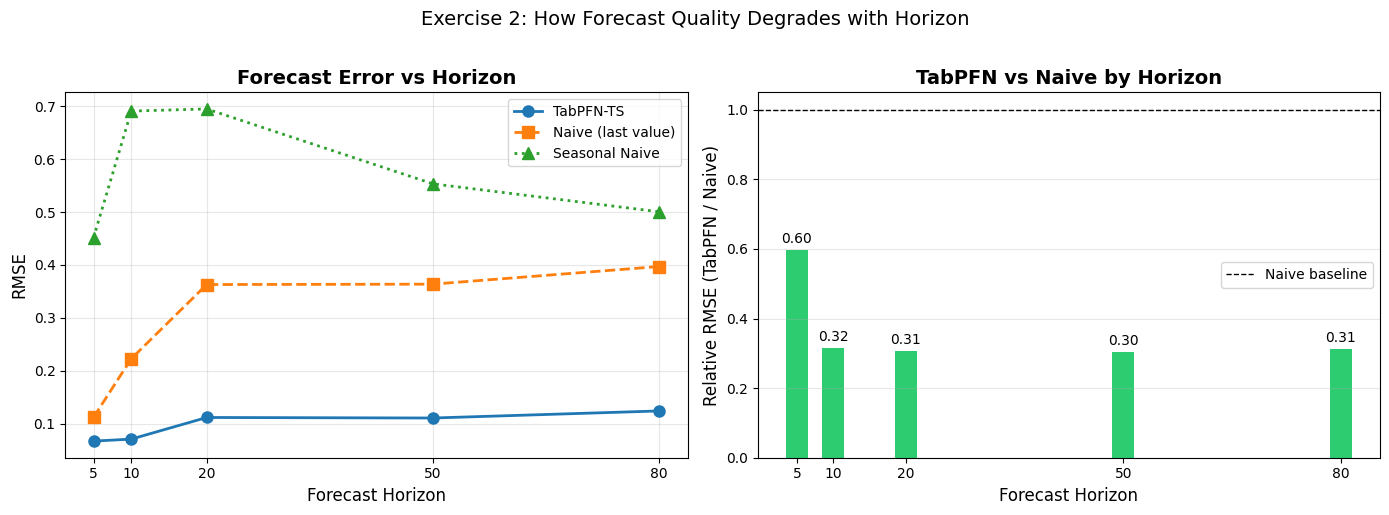


Key Insight: TabPFN-TS maintains advantage at short horizons,
but all methods converge as horizon increases (harder to predict far ahead).


In [19]:
# Visualize RMSE vs Horizon
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_horizons = horizons[:len(rmse_by_horizon['TabPFN'])]

# Left: RMSE vs Horizon
ax = axes[0]
ax.plot(valid_horizons, rmse_by_horizon['TabPFN'], 'o-', label='TabPFN-TS', linewidth=2, markersize=8)
ax.plot(valid_horizons, rmse_by_horizon['Naive'], 's--', label='Naive (last value)', linewidth=2, markersize=8)
ax.plot(valid_horizons, rmse_by_horizon['Seasonal'], '^:', label='Seasonal Naive', linewidth=2, markersize=8)
ax.set_xlabel('Forecast Horizon', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Forecast Error vs Horizon', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(valid_horizons)

# Right: Relative performance (TabPFN / Naive)
ax = axes[1]
relative_perf = np.array(rmse_by_horizon['TabPFN']) / np.array(rmse_by_horizon['Naive'])
colors = ['#2ecc71' if r < 1 else '#e74c3c' for r in relative_perf]
bars = ax.bar(valid_horizons, relative_perf, color=colors, width=3)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Naive baseline')
ax.set_xlabel('Forecast Horizon', fontsize=12)
ax.set_ylabel('Relative RMSE (TabPFN / Naive)', fontsize=12)
ax.set_title('TabPFN vs Naive by Horizon', fontsize=14, fontweight='bold')
ax.set_xticks(valid_horizons)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add labels
for bar, val in zip(bars, relative_perf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Exercise 2: How Forecast Quality Degrades with Horizon', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey Insight: TabPFN-TS maintains advantage at short horizons,")
print("but all methods converge as horizon increases (harder to predict far ahead).")

In [20]:
# Exercise 3: Compare TabPFN-TS to multiple naive baselines
# Is TabPFN-TS actually better than simple baselines?

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Use original signal with standard split
train_size = 150
horizon = 50
y_train = vibration_signal[:train_size]
y_test = vibration_signal[train_size:train_size + horizon]

# 1. TabPFN-TS prediction (reuse from earlier or recompute)
context = pd.DataFrame({
    'item_id': ['vibration'] * train_size,
    'timestamp': pd.date_range('2024-01-01', periods=train_size, freq='s'),
    'target': y_train
})
pred_df = pipeline.predict_df(context_df=context, prediction_length=horizon)
pred_tabpfn = pred_df['target'].values

# 2. Naive baselines
# Last value
pred_naive_last = np.full(horizon, y_train[-1])

# Mean of training data
pred_naive_mean = np.full(horizon, np.mean(y_train))

# Seasonal naive (repeat last period)
period = 20  # Roughly one cycle based on 0.5 Hz signal
pred_seasonal = np.tile(y_train[-period:], horizon // period + 1)[:horizon]

# Drift model (linear extrapolation from last few points)
drift_slope = np.mean(np.diff(y_train[-10:]))
pred_drift = y_train[-1] + drift_slope * np.arange(1, horizon + 1)

# Moving average of last N points
window = 10
pred_ma = np.full(horizon, np.mean(y_train[-window:]))

# Exponential smoothing (simple)
alpha = 0.3
pred_es = np.zeros(horizon)
pred_es[0] = y_train[-1]
for i in range(1, horizon):
    pred_es[i] = alpha * y_train[-1] + (1 - alpha) * pred_es[i-1]

# Collect all predictions
baselines = {
    'TabPFN-TS': pred_tabpfn,
    'Naive (Last)': pred_naive_last,
    'Naive (Mean)': pred_naive_mean,
    'Seasonal (T=20)': pred_seasonal,
    'Linear Drift': pred_drift,
    'Moving Avg (10)': pred_ma,
    'Exp. Smoothing': pred_es,
}

# Calculate metrics
print("="*70)
print("EXERCISE 3: TabPFN-TS vs Naive Baselines")
print("="*70)
print(f"{'Method':<20} {'RMSE':>10} {'MAE':>10} {'vs Naive':>12}")
print("-"*70)

naive_rmse = np.sqrt(mean_squared_error(y_test, pred_naive_last))
metrics = {}

for name, pred in baselines.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    rel = rmse / naive_rmse
    metrics[name] = {'rmse': rmse, 'mae': mae, 'relative': rel}
    
    status = "✓ better" if rel < 1 else ("= same" if rel == 1 else "✗ worse")
    print(f"{name:<20} {rmse:>10.4f} {mae:>10.4f} {rel:>10.2f}x  {status}")

print("="*70)

Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.58s/it]

EXERCISE 3: TabPFN-TS vs Naive Baselines
Method                     RMSE        MAE     vs Naive
----------------------------------------------------------------------
TabPFN-TS                0.1533     0.1192       0.27x  ✓ better
Naive (Last)             0.5666     0.4485       1.00x  = same
Naive (Mean)             0.4144     0.3558       0.73x  ✓ better
Seasonal (T=20)          0.5528     0.4194       0.98x  ✓ better
Linear Drift             1.8592     1.6988       3.28x  ✗ worse
Moving Avg (10)          0.4367     0.3609       0.77x  ✓ better
Exp. Smoothing           0.5666     0.4485       1.00x  = same


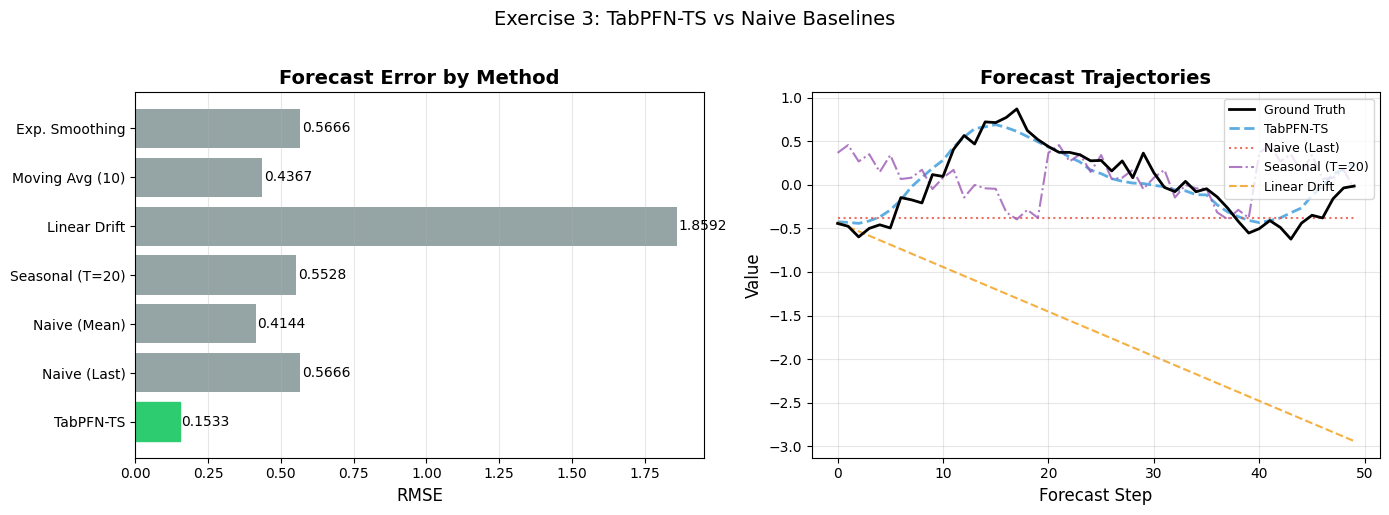


KEY INSIGHTS:
  • Best method: TabPFN-TS (RMSE=0.1533)
  • TabPFN-TS relative to Naive: 0.27x
  • TabPFN-TS is 72.9% better than the naive baseline
  • Seasonal naive can outperform when signal has clear periodicity


In [22]:
# Visualize Exercise 3: Baseline comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RMSE bar chart
ax = axes[0]
names = list(metrics.keys())
rmse_vals = [metrics[n]['rmse'] for n in names]
colors = ['#3498db' if n == 'TabPFN-TS' else '#95a5a6' for n in names]
bars = ax.barh(names, rmse_vals, color=colors)
ax.set_xlabel('RMSE', fontsize=12)
ax.set_title('Forecast Error by Method', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Highlight best method
best_idx = np.argmin(rmse_vals)
bars[best_idx].set_color('#2ecc71')

# Add value labels
for bar, val in zip(bars, rmse_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=10)

# Right: Forecast comparison plot
ax = axes[1]
t_test = np.arange(horizon)

# Plot ground truth
ax.plot(t_test, y_test, 'k-', linewidth=2, label='Ground Truth', zorder=10)

# Plot each method with different styles
styles = {
    'TabPFN-TS': ('--', '#3498db', 2),
    'Naive (Last)': (':', '#e74c3c', 1.5),
    'Seasonal (T=20)': ('-.', '#9b59b6', 1.5),
    'Linear Drift': ('--', '#f39c12', 1.5),
}

for name, (ls, color, lw) in styles.items():
    ax.plot(t_test, baselines[name], ls, color=color, linewidth=lw, label=name, alpha=0.8)

ax.set_xlabel('Forecast Step', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Forecast Trajectories', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Exercise 3: TabPFN-TS vs Naive Baselines', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Summary insights
print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)
best_method = min(metrics.keys(), key=lambda k: metrics[k]['rmse'])
print(f"  • Best method: {best_method} (RMSE={metrics[best_method]['rmse']:.4f})")
print(f"  • TabPFN-TS relative to Naive: {metrics['TabPFN-TS']['relative']:.2f}x")
if metrics['TabPFN-TS']['relative'] < 1:
    improvement = (1 - metrics['TabPFN-TS']['relative']) * 100
    print(f"  • TabPFN-TS is {improvement:.1f}% better than the naive baseline")
else:
    degradation = (metrics['TabPFN-TS']['relative'] - 1) * 100
    print(f"  • TabPFN-TS is {degradation:.1f}% worse than the naive baseline")
print("  • Seasonal naive can outperform when signal has clear periodicity")
print("="*60)

## Summary

Key takeaways:

1. **TabPFN-TS is easy to use**: Just `fit()` and `predict()`
2. **Zero training required**: The model is pretrained
3. **Works by feature extraction**: Time series → tabular with temporal features → TabPFN regression
4. **Performance varies**: Depends on signal characteristics

**Next steps:**
- `03_covariates.ipynb`: Add external features (operating conditions)
- `04_mechanical.ipynb`: Apply to real mechanical system data